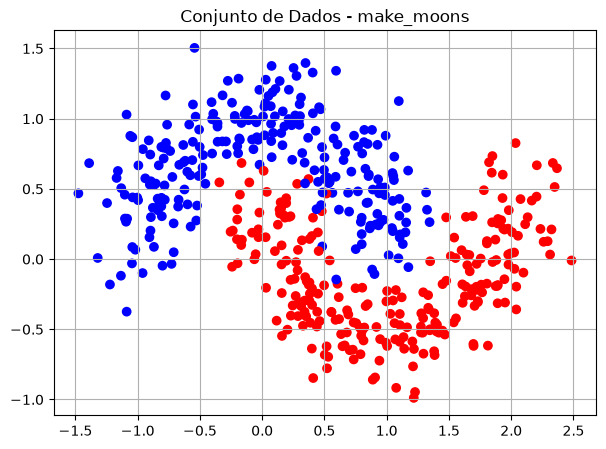

Treino: 350
Validação: 75
Teste: 75
Treinando modelo com 5 neurônios
Validation Loss: 0.25781723856925964
Treinando modelo com 10 neurônios
Validation Loss: 0.04319141432642937
Treinando modelo com 20 neurônios
Validation Loss: 0.04587341099977493
Treinando modelo com 50 neurônios
Validation Loss: 0.05928453430533409


MELHOR MODELO
Neurônios: 10
Validation Loss: 0.04319141432642937


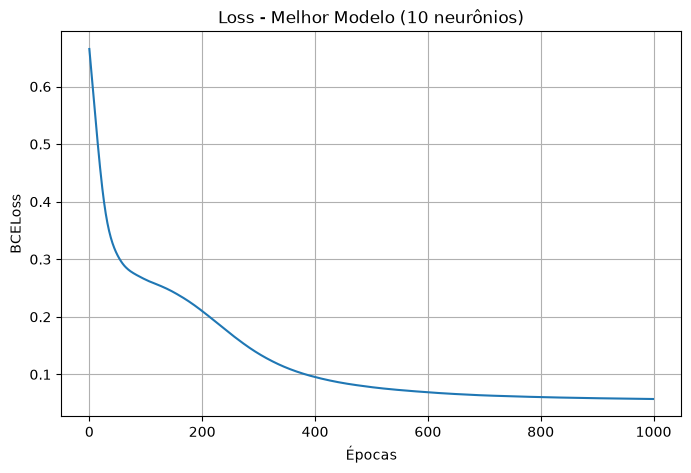


Acurácia no teste: 0.9866666666666667


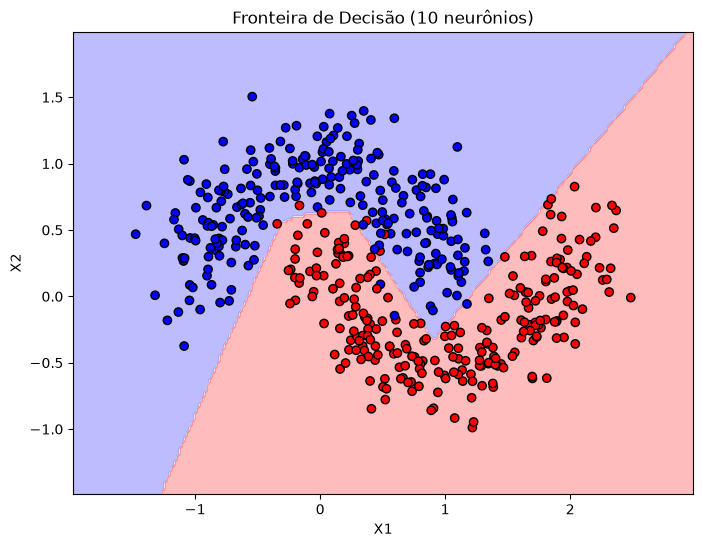

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

import torch
import torch.nn as nn
import torch.optim as optim

# ==========================================================
# 1. Gerando os dados
# ==========================================================

X, y = make_moons(
    n_samples=500,
    noise=0.2,
    random_state=42
)

plt.figure(figsize=(7,5))
plt.scatter(X[:,0], X[:,1], c=y, cmap="bwr")
plt.title("Conjunto de Dados - make_moons")
plt.grid(True)
plt.show()

# ==========================================================
# 2. Divisão treino / validação / teste
# ==========================================================

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

print("Treino:", len(X_train))
print("Validação:", len(X_val))
print("Teste:", len(X_test))

# ==========================================================
# 3. Conversão para Tensor
# ==========================================================

X_train_t = torch.FloatTensor(X_train)
X_val_t = torch.FloatTensor(X_val)
X_test_t = torch.FloatTensor(X_test)

y_train_t = torch.FloatTensor(y_train.reshape(-1,1))
y_val_t = torch.FloatTensor(y_val.reshape(-1,1))
y_test_t = torch.FloatTensor(y_test.reshape(-1,1))

# ==========================================================
# 4. Modelo MLP
# ==========================================================

class MLP(nn.Module):

    def __init__(self, hidden):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(2, hidden),
            nn.ReLU(),

            nn.Linear(hidden,1),
            nn.Sigmoid()

        )

    def forward(self,x):
        return self.net(x)

# ==========================================================
# 5. Treinamento
# ==========================================================

hidden_neurons = [5,10,20,50]

best_model = None
best_hidden = None
best_val_loss = float("inf")
best_losses = []

results = {}

for hidden in hidden_neurons:

    print("="*40)
    print(f"Treinando modelo com {hidden} neurônios")

    model = MLP(hidden)

    criterion = nn.BCELoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=0.01
    )

    losses = []

    epochs = 1000

    for epoch in range(epochs):

        output = model(X_train_t)

        loss = criterion(output,y_train_t)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        losses.append(loss.item())

    with torch.no_grad():

        val_output = model(X_val_t)

        val_loss = criterion(
            val_output,
            y_val_t
        ).item()

    results[hidden] = val_loss

    print("Validation Loss:", val_loss)

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        best_model = model

        best_hidden = hidden

        best_losses = losses

# ==========================================================
# 6. Melhor modelo
# ==========================================================

print("\n")
print("="*50)
print("MELHOR MODELO")
print("="*50)

print("Neurônios:", best_hidden)

print("Validation Loss:", best_val_loss)

# ==========================================================
# 7. Gráfico da Loss
# ==========================================================

plt.figure(figsize=(8,5))

plt.plot(best_losses)

plt.title(f"Loss - Melhor Modelo ({best_hidden} neurônios)")

plt.xlabel("Épocas")

plt.ylabel("BCELoss")

plt.grid(True)

plt.show()

# ==========================================================
# 8. Avaliação no conjunto de teste
# ==========================================================

with torch.no_grad():

    probs = best_model(X_test_t)

    preds = (probs >= 0.5).float()

accuracy = accuracy_score(
    y_test,
    preds.numpy()
)

print("\nAcurácia no teste:", accuracy)

# ==========================================================
# 9. Fronteira de decisão
# ==========================================================

x_min = X[:,0].min()-0.5
x_max = X[:,0].max()+0.5

y_min = X[:,1].min()-0.5
y_max = X[:,1].max()+0.5

xx, yy = np.meshgrid(

    np.arange(x_min,x_max,0.02),

    np.arange(y_min,y_max,0.02)

)

grid = np.c_[

    xx.ravel(),

    yy.ravel()

]

grid_tensor = torch.FloatTensor(grid)

with torch.no_grad():

    Z = best_model(grid_tensor)

    Z = (Z>=0.5).float().numpy()

Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,6))

plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.3,
    cmap="bwr"
)

plt.scatter(
    X[:,0],
    X[:,1],
    c=y,
    cmap="bwr",
    edgecolors="k"
)

plt.title(f"Fronteira de Decisão ({best_hidden} neurônios)")

plt.xlabel("X1")

plt.ylabel("X2")

plt.show()